<a href="https://colab.research.google.com/github/jioring4351/hongong-ML-study/blob/main/Chapter8/8_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 합성곱 신경망을 사용한 이미지 분류

8-1애서 배웠던 내용을 패션 MNIST에 적용해보기

In [4]:
#데이터 가져오기 및 전처리
#완전 연결 신경망에서는 입력 이미지를 밀집층에 연결하기 위해 일렬로 펼쳐야했지만 합성곱 신경망은 2차원 이미지 그대로 사용함.
import keras
from sklearn.model_selection import train_test_split

#데이터
(train_input, train_target), (test_input, test_target) = \
keras.datasets.fashion_mnist.load_data()

#전처리((48000, 28, 28) 크기를 (48000, 28, 28, 1)로 바꾸어줌)
train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0

#검증세트 나누기
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)

## 첫번째 합성곱 층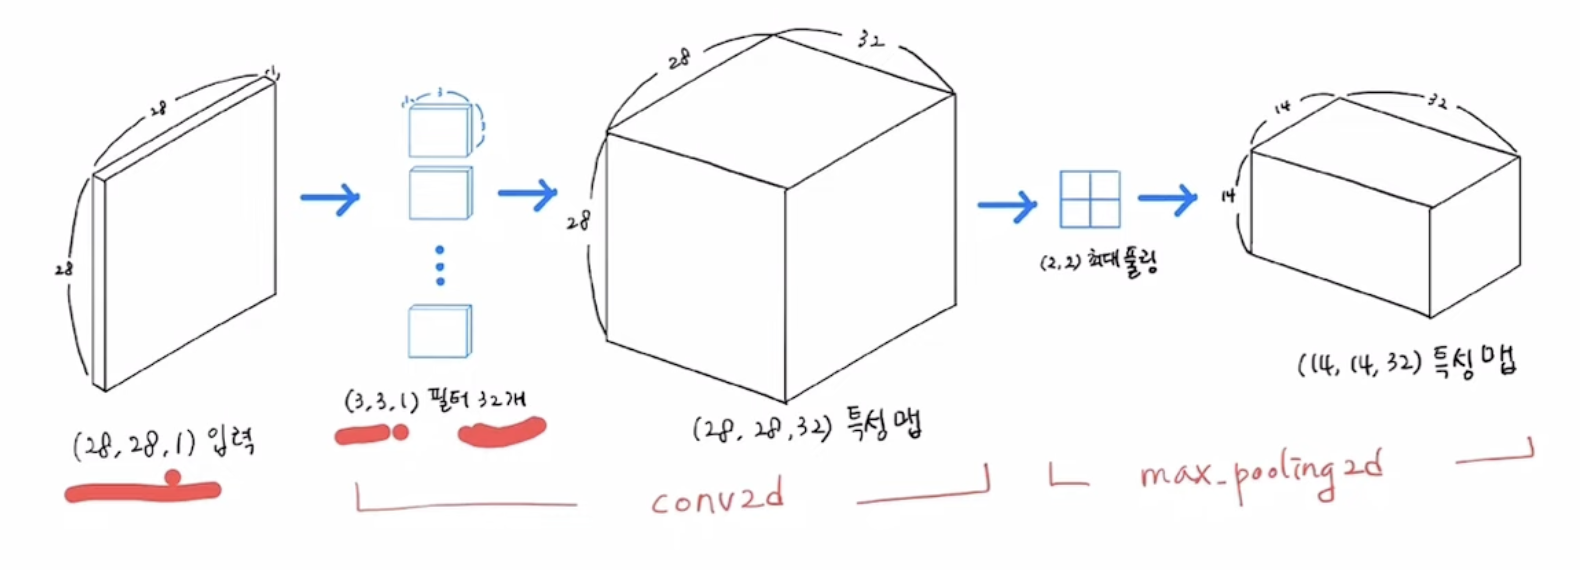

In [5]:
#합성곱 신경망 만들기
#필터는 32개
model = keras.Sequential()
model.add(keras.layers.Input(shape=(28, 28, 1)))
model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'))
model.add(keras.layers.MaxPooling2D(2))

## 두번째 합성곱 층과 밀집층
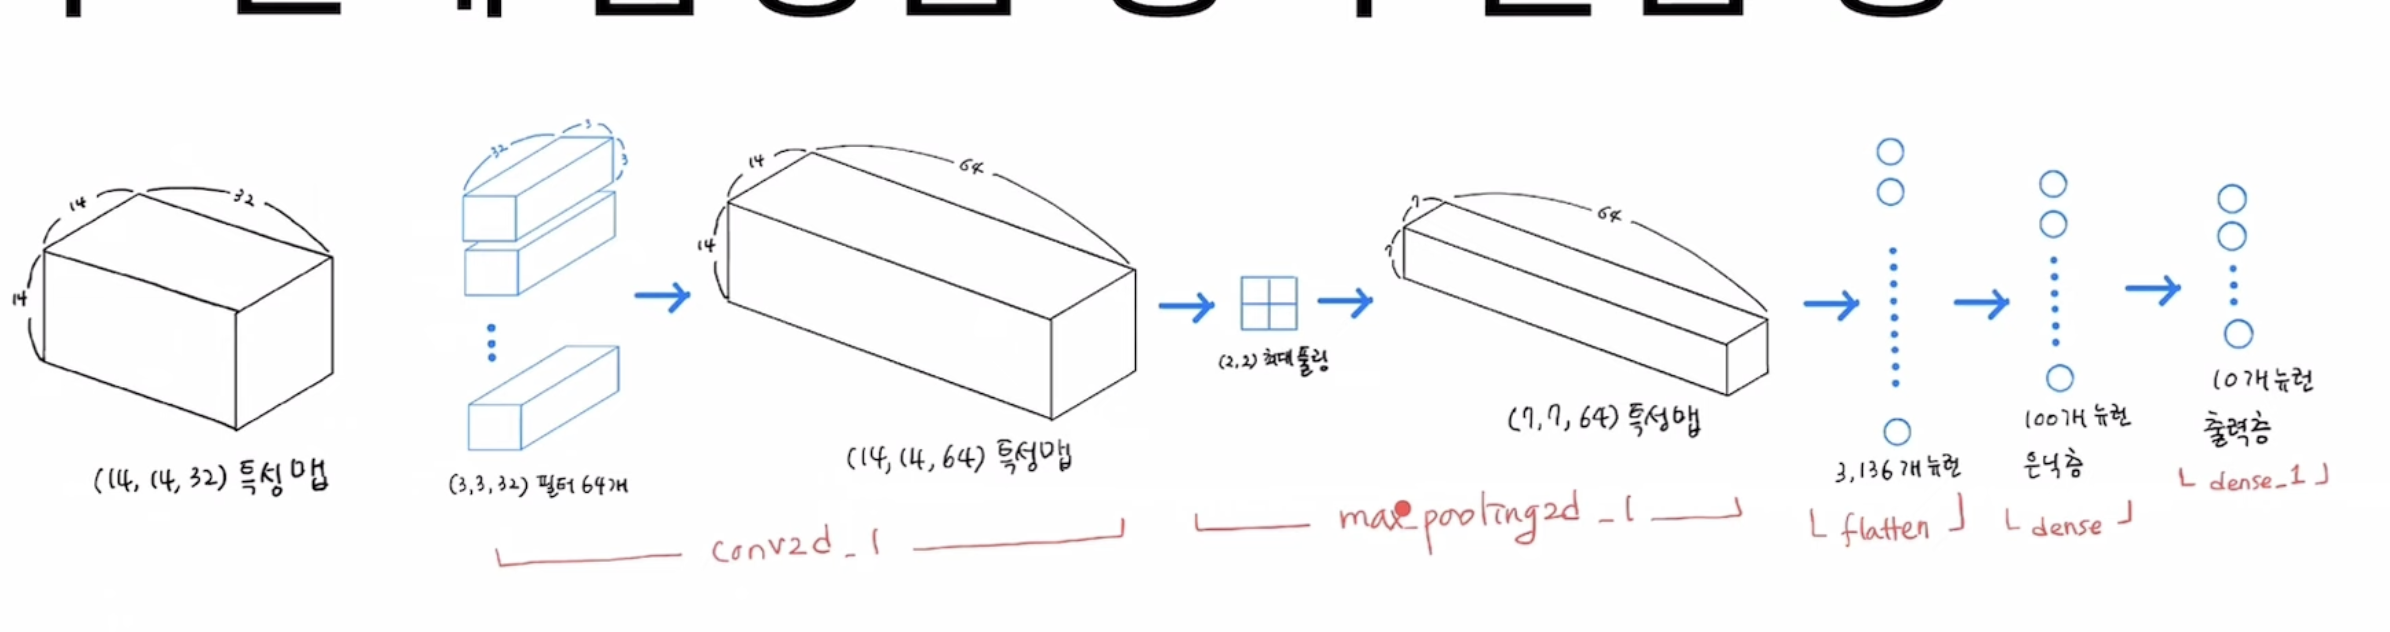

In [7]:
#두번째 합성곱 층
#필터는 64개
model.add(keras.layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'))
model.add(keras.layers.MaxPooling2D(2))

In [8]:
#밀집층과 출력층
model.add(keras.layers.Flatten()) #1차원으로 펼치기
model.add(keras.layers.Dense(100, activation='relu')) #100개 뉴런의 은닉층
model.add(keras.layers.Dropout(0.4))  #과대적합을 막기위한 드롭아웃층
model.add(keras.layers.Dense(10, activation='softmax'))  #10개 뉴런의 출력층

In [9]:
#모델구조 출력(각 차원의 수들과 위에 그림과 함꼐 봐보기)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,526 (1.27 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

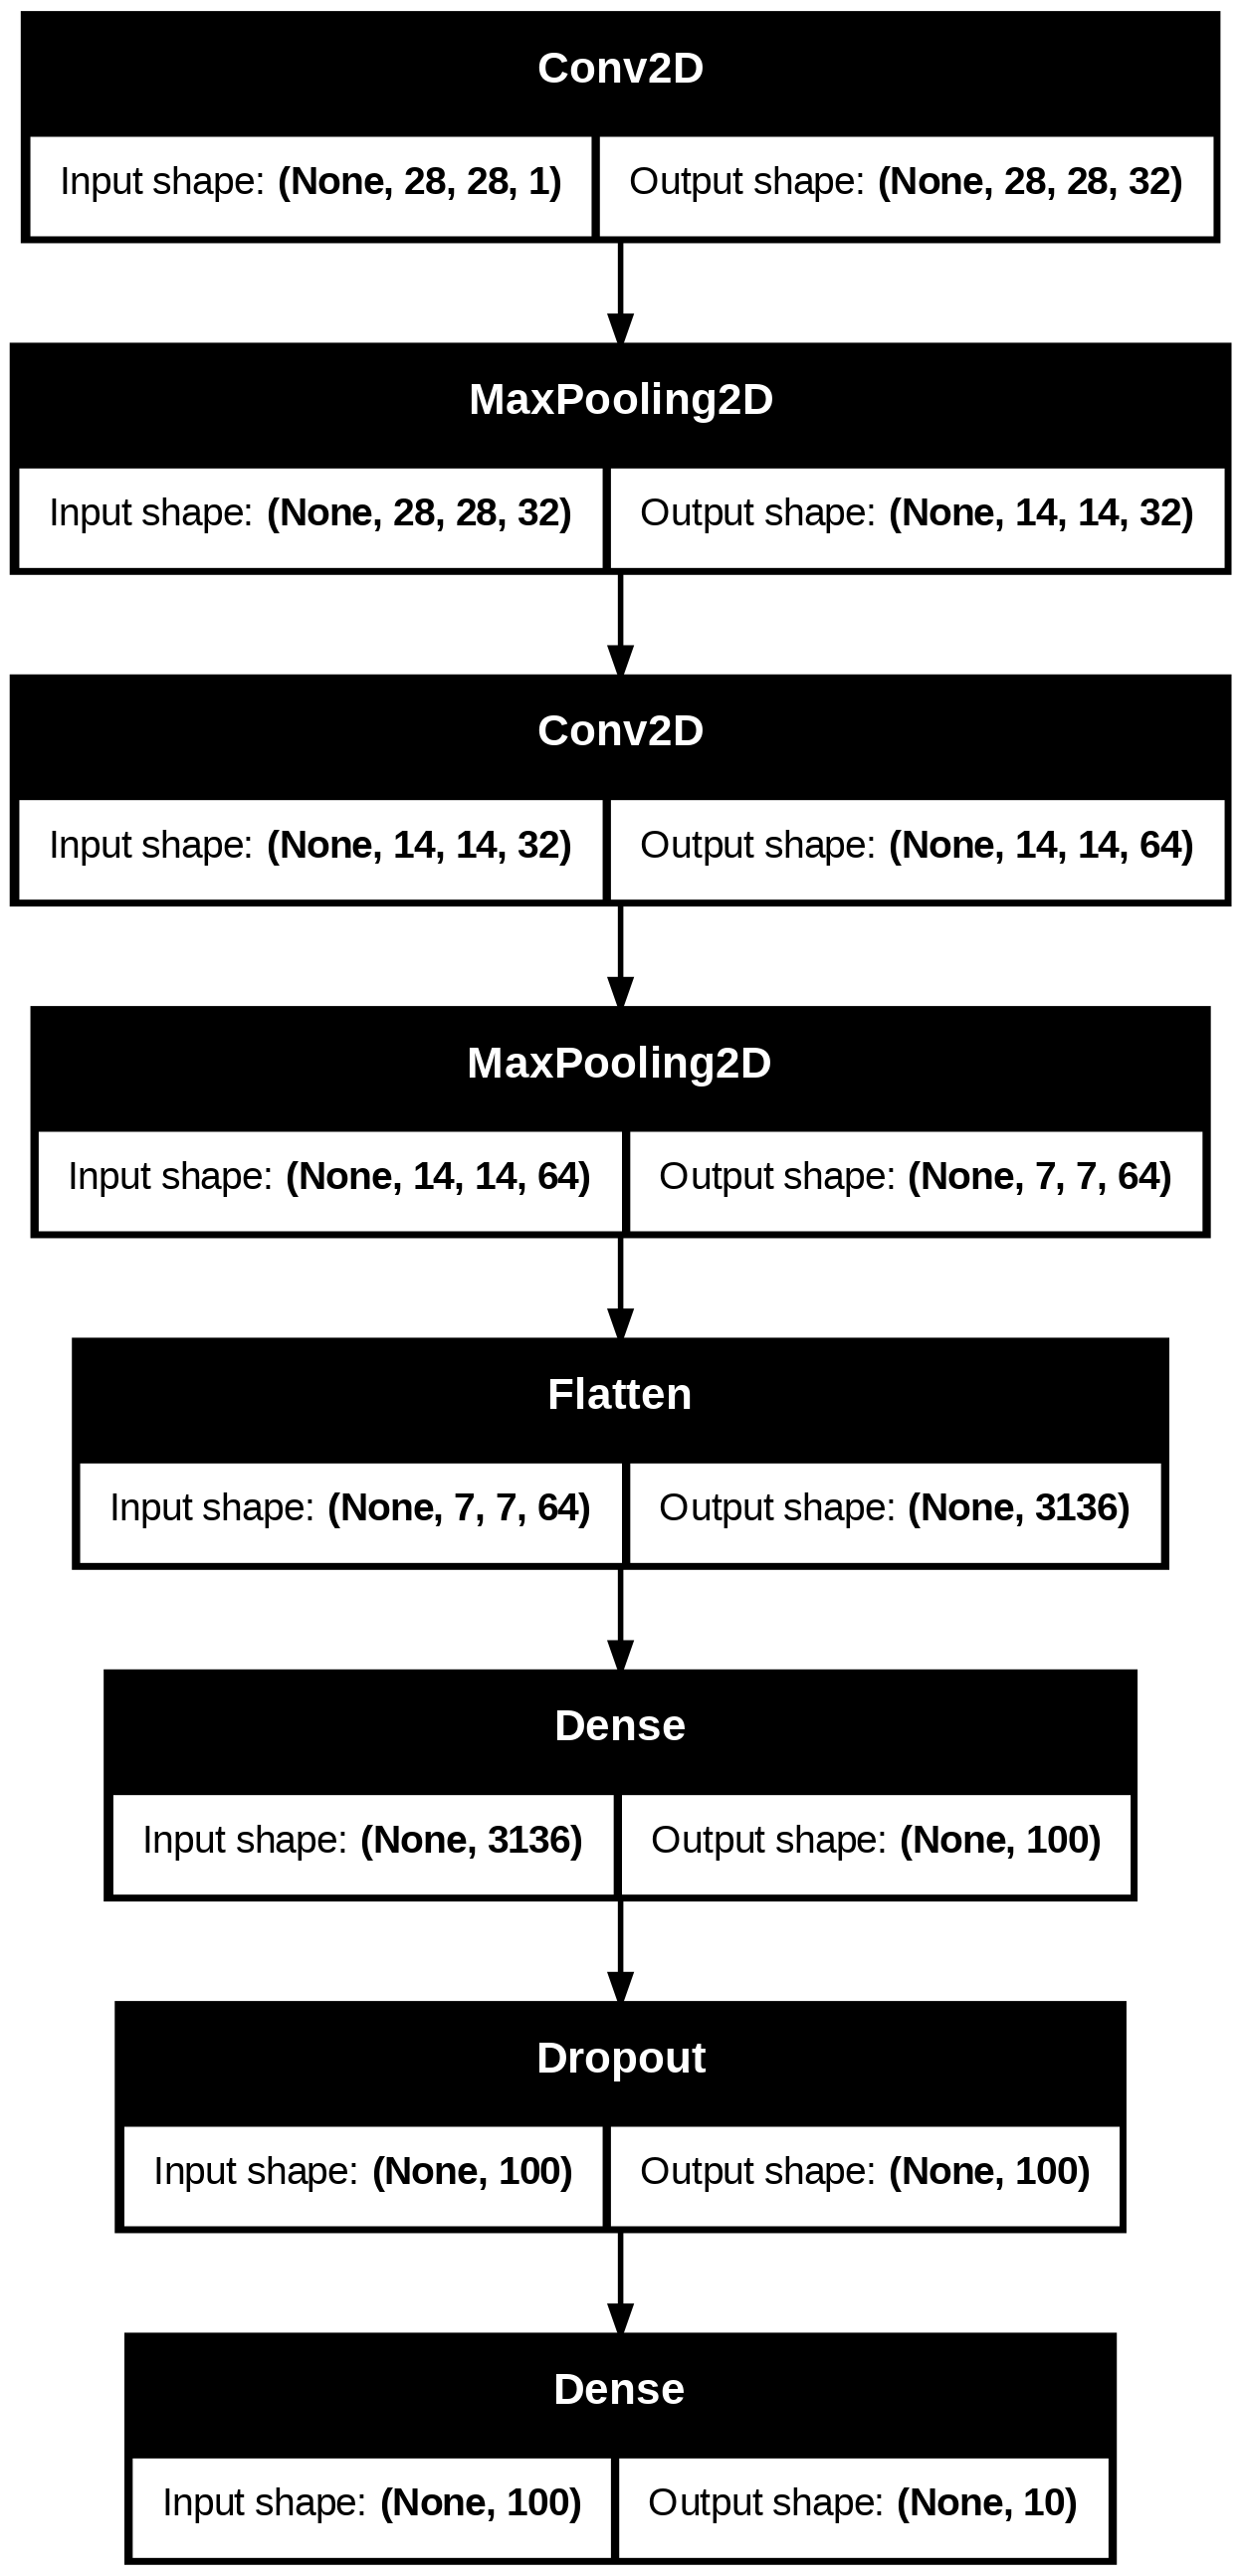

In [11]:
#층의 구성을 그림으로 표현해보기
keras.utils.plot_model(model, show_shapes=True)

## 모델 훈련

In [13]:
#컴파일(옵티마이저 사용)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])\

#콜백
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-cnn-model.keras', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)

#훈련
history = model.fit(train_scaled, train_target, epochs=20,
                    validation_data=(val_scaled, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 62s 39ms/step - accuracy: 0.8193 - loss: 0.5025 - val_accuracy: 0.8829 - val_loss: 0.3158
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 60s 40ms/step - accuracy: 0.8792 - loss: 0.3332 - val_accuracy: 0.8982 - val_loss: 0.2763
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 59s 39ms/step - accuracy: 0.8978 - loss: 0.2836 - val_accuracy: 0.9028 - val_loss: 0.2586
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 59s 40ms/step - accuracy: 0.9090 - loss: 0.2510 - val_accuracy: 0.9153 - val_loss: 0.2276
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 60s 40ms/step - accuracy: 0.9165 - loss: 0.2265 - val_accuracy: 0.9149 - val_loss: 0.2292
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 40ms/step - accuracy: 0.9221 - loss: 0.2075 - val_accuracy: 0.9170 - val_loss: 0.2252
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 80s 38ms/step - accuracy: 0.9306 - loss: 0.1878 - val_accuracy: 0.9166 - val_loss: 0.2217
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 62s 41ms/step - accuracy: 0.9354 -

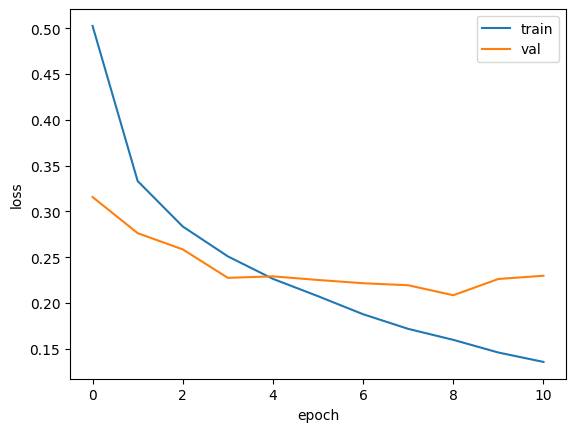

In [14]:
#손실 그래프 그려보기
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [15]:
#성능평가
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9237 - loss: 0.2086


[0.20859237015247345, 0.9236666560173035]

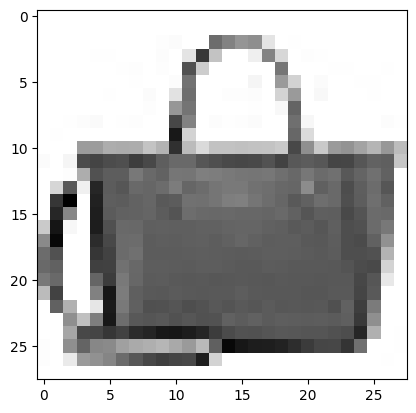

In [16]:
#검증세트의 샘플로 예측해보기
plt.imshow(val_scaled[0].reshape(28, 28), cmap='gray_r')
plt.show()

In [18]:
#모델이 이 이미지에 대해 어떤 예측을 할까?
preds = model.predict(val_scaled[0:1])
print(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
[[3.3596336e-19 5.0100217e-27 1.9067364e-23 4.1831852e-21 1.7812045e-22
  5.9515533e-17 1.3761110e-19 4.0203627e-16 1.0000000e+00 2.8950931e-18]]


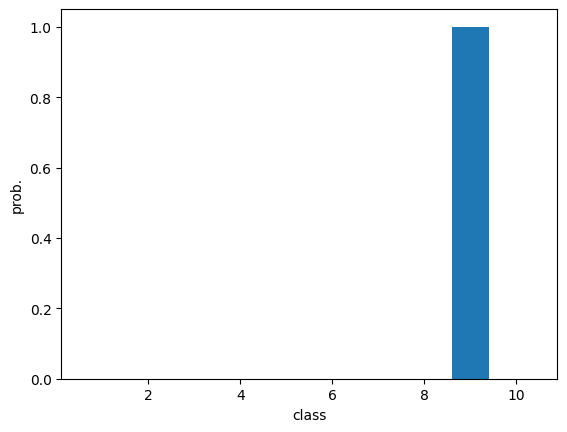

In [19]:
#막대 그래프로 그려보기
plt.bar(range(1,11), preds[0])
plt.xlabel('class')
plt.ylabel('prob.')
plt.show()